In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv('E_Commerce_Dataset.csv')

In [21]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [22]:
# Check exact count of missing values in each column
missing_info = df.isnull().sum()
print("Missing Values Per Column:")
print(missing_info[missing_info > 0])

Missing Values Per Column:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [23]:
# List of numerical columns with missing values
missing_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 
    'OrderCount', 'DaySinceLastOrder'
]

# Fill missing values with median by explicit assignment
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

# Verify if all missing values are resolved
print("Remaining Missing Values across entire dataset:", df.isnull().sum().sum())

Remaining Missing Values across entire dataset: 0


Total Customers: 5630
Churned Customers: 948
Retained Customers: 4682
Overall Churn Rate: 16.84%


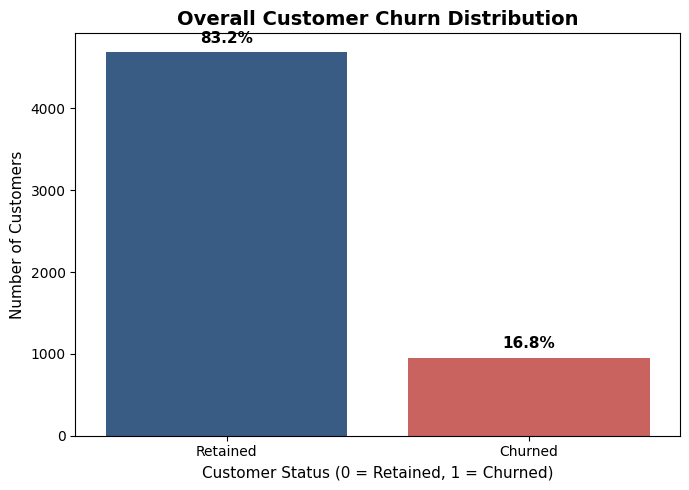

In [24]:
# 1. Calculate overall churn count and percentage
total_customers = len(df)
churned_customers = df['Churn'].sum()
retained_customers = total_customers - churned_customers
churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churned_customers}")
print(f"Retained Customers: {retained_customers}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# 2. Visualize Churn Distribution using Seaborn
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'])

plt.title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])

# Add percentage labels on top of the bars
for p in ax.patches:
    percentage = f'{(100 * p.get_height() / total_customers):.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=300)
plt.show()

           Tenure_Group  Total_Customers  Churned_Customers  Churn_Rate  \
0      0-6 Months (New)             2150                697    0.324186   
1    12+ Months (Loyal)             1896                 95    0.050105   
2  6-12 Months (Medium)             1584                156    0.098485   

   Churn_Rate_%  
0     32.418605  
1      5.010549  
2      9.848485  


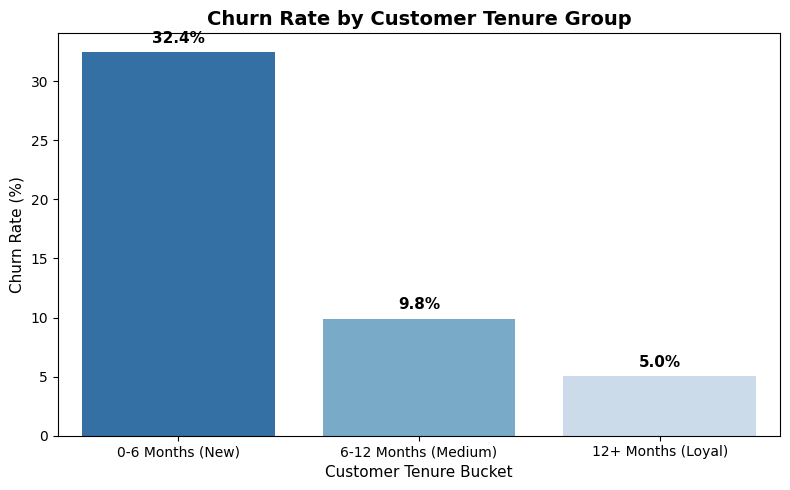

In [25]:
# 1. Create Tenure Buckets
def tenure_group(tenure):
    if tenure <= 6:
        return '0-6 Months (New)'
    elif tenure <= 12:
        return '6-12 Months (Medium)'
    else:
        return '12+ Months (Loyal)'

df['Tenure_Group'] = df['Tenure'].apply(tenure_group)

# 2. Calculate Churn Rate per Tenure Group
tenure_churn = df.groupby('Tenure_Group')['Churn'].agg(['count', 'sum', 'mean']).reset_index()
tenure_churn.columns = ['Tenure_Group', 'Total_Customers', 'Churned_Customers', 'Churn_Rate']
tenure_churn['Churn_Rate_%'] = tenure_churn['Churn_Rate'] * 100

print(tenure_churn)

# 3. Visualize Churn Rate by Tenure Group
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=tenure_churn, 
    x='Tenure_Group', 
    y='Churn_Rate_%', 
    palette='Blues_r',
    order=['0-6 Months (New)', '6-12 Months (Medium)', '12+ Months (Loyal)']
)

plt.title('Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Customer Tenure Bucket', fontsize=11)
plt.ylabel('Churn Rate (%)', fontsize=11)

# Annotate bars with exact percentages
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=300)
plt.show()

Churn Rate by Complaint Status:
   Complain     Churn  Churn_Rate_%
0         0  0.109290     10.928962
1         1  0.316708     31.670823


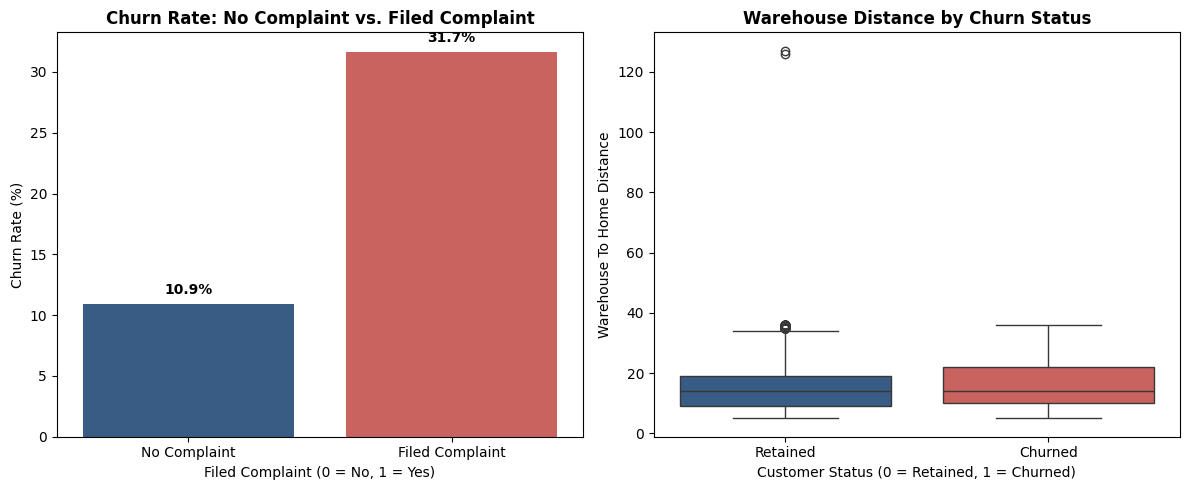

In [26]:
# 1. Churn Rate by Complaint Status
complaint_churn = df.groupby('Complain')['Churn'].mean().reset_index()
complaint_churn['Churn_Rate_%'] = complaint_churn['Churn'] * 100

print("Churn Rate by Complaint Status:")
print(complaint_churn)

# 2. Visualize Complaint Impact & Warehouse Distance
plt.figure(figsize=(12, 5))

# Subplot 1: Complaint vs Churn Rate
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=complaint_churn, x='Complain', y='Churn_Rate_%', palette=['#2b5c8f', '#d9534f'])
plt.title('Churn Rate: No Complaint vs. Filed Complaint', fontsize=12, fontweight='bold')
plt.xlabel('Filed Complaint (0 = No, 1 = Yes)', fontsize=10)
plt.ylabel('Churn Rate (%)', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['No Complaint', 'Filed Complaint'])

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

# Subplot 2: Distance from Warehouse vs Churn
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Churn', y='WarehouseToHome', palette=['#2b5c8f', '#d9534f'])
plt.title('Warehouse Distance by Churn Status', fontsize=12, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=10)
plt.ylabel('Warehouse To Home Distance', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('complaint_and_distance_impact.png', dpi=300)
plt.show()

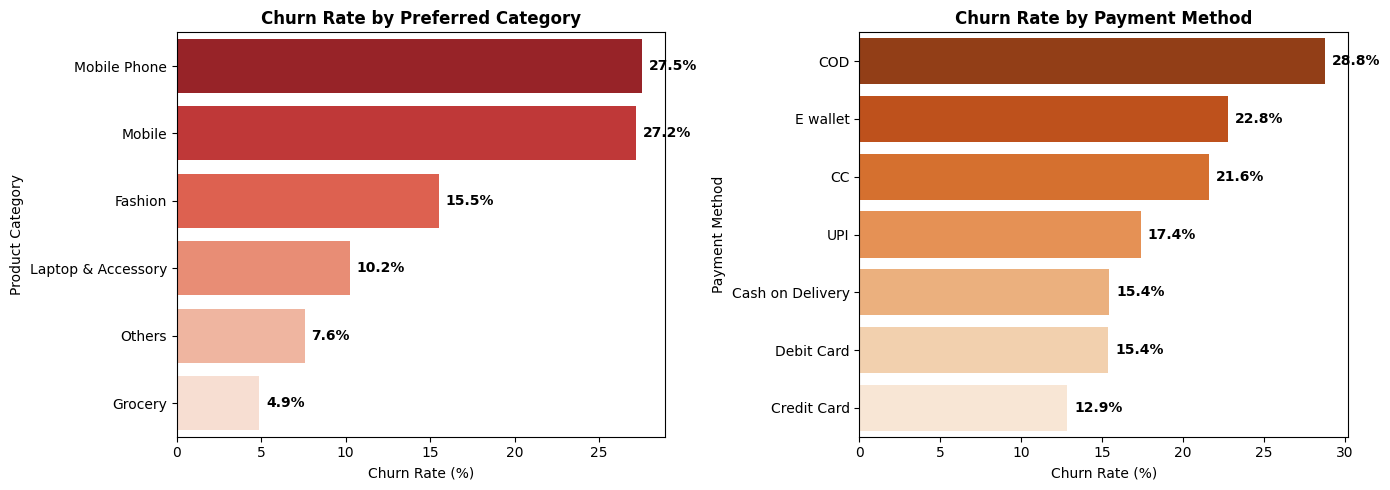

In [27]:
# 1. Churn Rate by Preferred Order Category
cat_churn = df.groupby('PreferedOrderCat')['Churn'].agg(['count', 'mean']).reset_index()
cat_churn.columns = ['Category', 'Total_Orders', 'Churn_Rate']
cat_churn['Churn_Rate_%'] = cat_churn['Churn_Rate'] * 100
cat_churn = cat_churn.sort_values(by='Churn_Rate_%', ascending=False)

# 2. Churn Rate by Preferred Payment Mode
pay_churn = df.groupby('PreferredPaymentMode')['Churn'].agg(['count', 'mean']).reset_index()
pay_churn.columns = ['Payment_Mode', 'Total_Orders', 'Churn_Rate']
pay_churn['Churn_Rate_%'] = pay_churn['Churn_Rate'] * 100
pay_churn = pay_churn.sort_values(by='Churn_Rate_%', ascending=False)

# 3. Visualize Category and Payment Mode Impact
plt.figure(figsize=(14, 5))

# Subplot 1: Order Category Churn
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=cat_churn, x='Churn_Rate_%', y='Category', palette='Reds_r')
plt.title('Churn Rate by Preferred Category', fontsize=12, fontweight='bold')
plt.xlabel('Churn Rate (%)', fontsize=10)
plt.ylabel('Product Category', fontsize=10)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                 textcoords='offset points')

# Subplot 2: Payment Mode Churn
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=pay_churn, x='Churn_Rate_%', y='Payment_Mode', palette='Oranges_r')
plt.title('Churn Rate by Payment Method', fontsize=12, fontweight='bold')
plt.xlabel('Churn Rate (%)', fontsize=10)
plt.ylabel('Payment Method', fontsize=10)

for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10, fontweight='bold', xytext=(5, 0),
                 textcoords='offset points')

plt.tight_layout()
plt.savefig('category_and_payment_churn.png', dpi=300)
plt.show()

Average Engagement Metrics by Churn Status:
   Churn  DaySinceLastOrder  HourSpendOnApp  OrderCount
0      0           4.709739        2.928663    2.992952
1      1           3.222574        2.964135    2.808017


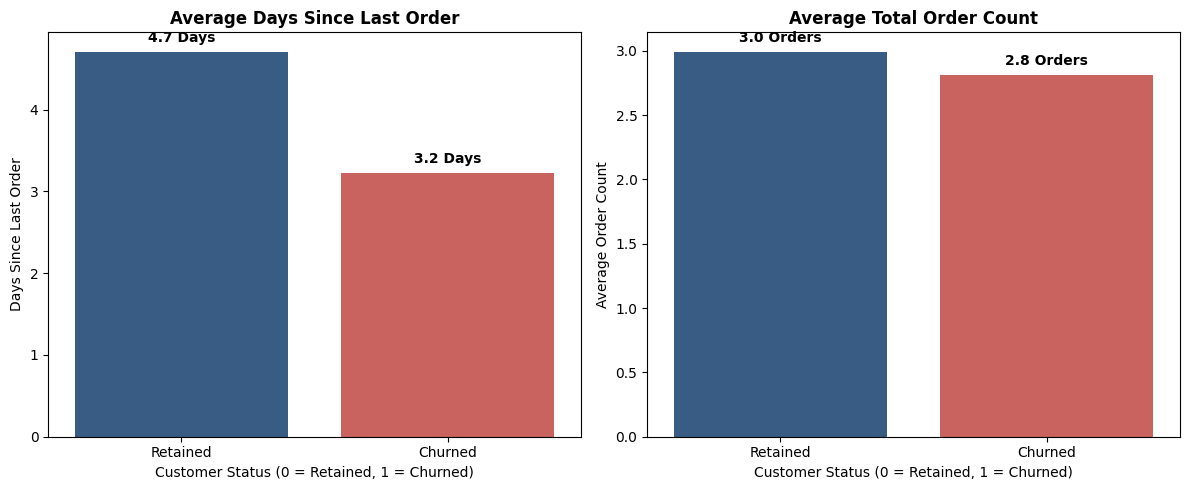

In [28]:
# 1. Summary stats for engagement metrics grouped by Churn
engagement_summary = df.groupby('Churn')[['DaySinceLastOrder', 'HourSpendOnApp', 'OrderCount']].mean().reset_index()
print("Average Engagement Metrics by Churn Status:")
print(engagement_summary)

# 2. Visualize Days Since Last Order vs Hour Spend On App
plt.figure(figsize=(12, 5))

# Subplot 1: Days Since Last Order
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=df, x='Churn', y='DaySinceLastOrder', palette=['#2b5c8f', '#d9534f'], ci=None)
plt.title('Average Days Since Last Order', fontsize=12, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=10)
plt.ylabel('Days Since Last Order', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])

for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f} Days', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

# Subplot 2: Order Count
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=df, x='Churn', y='OrderCount', palette=['#2b5c8f', '#d9534f'], ci=None)
plt.title('Average Total Order Count', fontsize=12, fontweight='bold')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)', fontsize=10)
plt.ylabel('Average Order Count', fontsize=10)
plt.xticks(ticks=[0, 1], labels=['Retained', 'Churned'])

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f} Orders', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.savefig('engagement_and_recency.png', dpi=300)
plt.show()